In [2]:
import pandas as pd

df = pd.read_csv('/content/all_tickets_processed_improved_v3.csv')

print(df.columns.tolist())

['Document', 'Topic_group']


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Dataset Shape: (47837, 2)

Columns:
['Document', 'Topic_group']

First 5 Rows:
                                            Document    Topic_group
0  connection with icon icon dear please setup ic...       Hardware
1  work experience user work experience user hi w...         Access
2  requesting for meeting requesting meeting hi p...       Hardware
3  reset passwords for external accounts re expir...         Access
4  mail verification warning hi has got attached ...  Miscellaneous

After Cleaning: (47837, 2)

Category Distribution:
Topic_group
Hardware                 13617
HR Support               10915
Access                    7125
Miscellaneous             7060
Storage                   2777
Purchase                  2464
Internal Project          2119
Administrative rights     1760
Name: count, dtype: int64

TF-IDF Shape: (47837, 10000)

MODEL PERFORMANCE
Accuracy: 0.8582

Classification Report:

                       precision    recall  f1-score   support

               Acces

<Figure size 1200x1000 with 0 Axes>

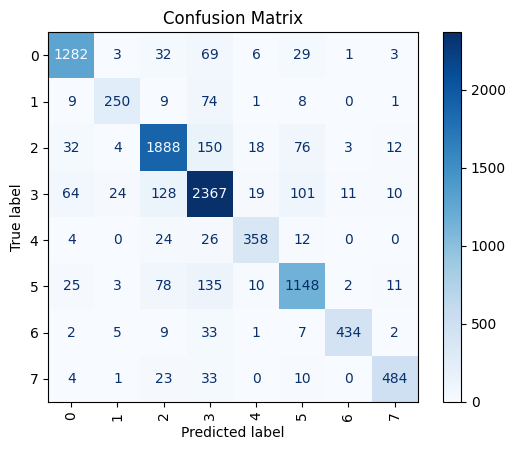


SAMPLE PREDICTIONS

Ticket: Need access to shared folder
Predicted Category: Storage

Ticket: Laptop is not starting
Predicted Category: Hardware

Ticket: Request for new software installation
Predicted Category: Purchase

Ticket: Printer is not working
Predicted Category: Hardware

Ticket: Need administrative rights on system
Predicted Category: Hardware

Predictions saved to ticket_predictions.csv


Category: Access
confluence
account
user
license
git
repository
card
password
locked
accounts


Category: Administrative rights
outlook
upgrade
exchange
issues
windows
outlook sent
install
software
assets
update


Category: HR Support
time
oracle
timecard
starter
error
leave
bucharest
time card
leaver
submit


Category: Hardware
monitor
ram
laptop
room
connection
meeting
phone
documents
certificate
calls


Category: Internal Project
code
project
pipeline
codes
setup
pipe
pipelines
unknown
pas
import


Category: Miscellaneous
approval
groups
change
approve
ticket
tickets
add
approved
owne

In [3]:
# =====================================================
# IT SERVICE TICKET CLASSIFICATION
# =====================================================

!pip install nltk -q

import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# =====================================================
# DOWNLOAD NLTK DATA
# =====================================================

nltk.download('stopwords')

# =====================================================
# LOAD DATASET
# =====================================================

df = pd.read_csv('/content/all_tickets_processed_improved_v3.csv')

print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
print(df.head())

# =====================================================
# REMOVE MISSING VALUES
# =====================================================

df = df[['Document', 'Topic_group']]

df.dropna(inplace=True)

print("\nAfter Cleaning:", df.shape)

# =====================================================
# CLASS DISTRIBUTION
# =====================================================

print("\nCategory Distribution:")
print(df['Topic_group'].value_counts())

# =====================================================
# TEXT CLEANING
# =====================================================

stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r'[^a-zA-Z ]', ' ', text)

    words = text.split()

    words = [
        word
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

df['clean_text'] = df['Document'].apply(clean_text)

# =====================================================
# TF-IDF
# =====================================================

vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=2
)

X = vectorizer.fit_transform(df['clean_text'])

y = df['Topic_group']

print("\nTF-IDF Shape:", X.shape)

# =====================================================
# TRAIN TEST SPLIT
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =====================================================
# MODEL
# =====================================================

model = LinearSVC()

model.fit(X_train, y_train)

# =====================================================
# PREDICTIONS
# =====================================================

predictions = model.predict(X_test)

# =====================================================
# EVALUATION
# =====================================================

accuracy = accuracy_score(
    y_test,
    predictions
)

print("\n===================================")
print("MODEL PERFORMANCE")
print("===================================")

print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        predictions
    )
)

# =====================================================
# CONFUSION MATRIX
# =====================================================

cm = confusion_matrix(
    y_test,
    predictions
)

plt.figure(figsize=(12,10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(
    cmap='Blues',
    xticks_rotation=90
)

plt.title(
    "Confusion Matrix"
)

plt.show()

# =====================================================
# SAMPLE PREDICTIONS
# =====================================================

sample_tickets = [

    "Need access to shared folder",

    "Laptop is not starting",

    "Request for new software installation",

    "Printer is not working",

    "Need administrative rights on system"
]

sample_clean = [
    clean_text(ticket)
    for ticket in sample_tickets
]

sample_vector = vectorizer.transform(
    sample_clean
)

sample_predictions = model.predict(
    sample_vector
)

print("\n===================================")
print("SAMPLE PREDICTIONS")
print("===================================")

for ticket, prediction in zip(
    sample_tickets,
    sample_predictions
):

    print("\nTicket:", ticket)
    print("Predicted Category:", prediction)

# =====================================================
# SAVE PREDICTIONS
# =====================================================

results = pd.DataFrame({

    "Ticket":
    sample_tickets,

    "Predicted_Category":
    sample_predictions
})

results.to_csv(
    "ticket_predictions.csv",
    index=False
)

print("\nPredictions saved to ticket_predictions.csv")

# =====================================================
# TOP FEATURES
# =====================================================

feature_names = vectorizer.get_feature_names_out()

for class_name in model.classes_:

    class_idx = list(
        model.classes_
    ).index(class_name)

    top_features = np.argsort(
        model.coef_[class_idx]
    )[-10:]

    print("\n")
    print("="*50)
    print("Category:", class_name)
    print("="*50)

    for idx in reversed(top_features):

        print(
            feature_names[idx]
        )

# =====================================================
# BUSINESS INSIGHTS
# =====================================================

print("\n===================================")
print("BUSINESS INSIGHTS")
print("===================================")

print("""
1. Incoming tickets can be automatically
   categorized into the correct support team.

2. Manual ticket routing effort is reduced.

3. Faster ticket assignment improves
   response times.

4. Support teams can focus on solving
   issues instead of sorting tickets.

5. Automated classification helps
   improve operational efficiency and
   customer satisfaction.
""")